# MÔ HÌNH PHÂN LỚP (CLASSIFICATION MODEL)

Notebook này xây dựng các mô hình phân lớp nhằm dự đoán xem một ngày chạy chiến dịch thuộc về nhóm **Control** hay **Test** dựa trên các chỉ số hiệu suất marketing.

### Ý nghĩa nghiệp vụ (Business Rationale):
- Việc phân loại Control vs Test không chỉ đơn thuần là phân biệt hai nhãn, mà nó giúp doanh nghiệp kiểm chứng xem **đặc trưng vận hành và hành vi khách hàng của hai chiến dịch có thực sự khác biệt** hay không.
- Nếu mô hình phân loại đạt được độ chính xác cao (accuracy > 50%), điều đó chứng minh chiến dịch Test đã tạo ra những thay đổi đáng kể trong phễu chuyển đổi so với Control.
- Phân tích độ quan trọng của các đặc trưng (Feature Importance) sẽ chỉ ra **những chỉ số nào là nguồn gốc tạo nên sự khác biệt này** (ví dụ: Test tập trung vào click và search hơn, trong khi Control tập trung vào hiển thị).

Giai đoạn này bao gồm:

* Chuẩn bị dữ liệu & Kỹ nghệ đặc trưng (Loại bỏ rò rỉ dữ liệu - leakage)
* Hồi quy Logistic (Logistic Regression)
* Mô hình Cây quyết định (Decision Tree Classifier)
* Mô hình Rừng ngẫu nhiên (Random Forest Classifier)
* Đánh giá mô hình (Accuracy, Confusion Matrix, ROC-AUC)
* Độ quan trọng đặc trưng & Diễn giải nghiệp vụ (Feature Importance & Business Interpretation)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/cleaned_marketing.csv')
df['date'] = pd.to_datetime(df['date'])

# Drop rows with missing values
df_clean = df.dropna().copy()
print(f'Dataset shape: {df_clean.shape}')
df_clean.head()

Dataset shape: (59, 11)


,campaign_name,date,spend_usd,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,control


## 1. Chuẩn bị dữ liệu (Data Preparation)

### 1.1 Loại bỏ Rò rỉ Dữ liệu (Data Leakage)

- Cột `purchase` là chỉ số mục tiêu (target outcome) của chiến dịch A/B test. Nếu giữ `purchase` làm feature đầu vào để dự đoán group (control vs test), mô hình sẽ bị rò rỉ dữ liệu (leakage), dẫn đến độ chính xác ảo và không phản ánh đúng hành vi phễu chuyển đổi.
- Do đó, ta **loại bỏ** `purchase` khỏi tập đặc trưng `feature_cols` của mô hình phân loại.

In [3]:
# Loại bỏ 'purchase' để tránh rò rỉ dữ liệu (data leakage)
feature_cols = ['spend_usd', 'impressions', 'reach', 'website_clicks',
                'searches', 'view_content', 'add_to_cart']

X = df_clean[feature_cols]
y = (df_clean['group'] == 'test').astype(int)  # 1 = test, 0 = control

print('Class distribution:')
print(y.value_counts().rename({0: 'Control', 1: 'Test'}))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')

Class distribution:
group
Test       30
Control    29
Name: count, dtype: int64

Training set: 44 samples
Testing set:  15 samples


## 2. Hồi quy Logistic (Logistic Regression)

In [4]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print('=== Logistic Regression ===')
print(f'Accuracy: {acc_lr:.4f}')
print(f'ROC-AUC:  {auc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Control', 'Test']))

=== Logistic Regression ===
Accuracy: 0.6667
ROC-AUC:  0.7679

              precision    recall  f1-score   support

     Control       0.75      0.43      0.55         7
        Test       0.64      0.88      0.74         8

    accuracy                           0.67        15
   macro avg       0.69      0.65      0.64        15
weighted avg       0.69      0.67      0.65        15



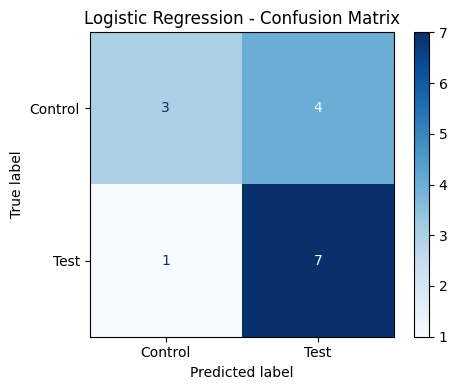

In [5]:
# Logistic Regression Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Control', 'Test'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

## 3. Mô hình Cây quyết định (Decision Tree Classifier)

In [6]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print('=== Decision Tree ===')
print(f'Accuracy: {acc_dt:.4f}')
print(f'ROC-AUC:  {auc_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['Control', 'Test']))

=== Decision Tree ===
Accuracy: 0.6667
ROC-AUC:  0.6786

              precision    recall  f1-score   support

     Control       0.67      0.57      0.62         7
        Test       0.67      0.75      0.71         8

    accuracy                           0.67        15
   macro avg       0.67      0.66      0.66        15
weighted avg       0.67      0.67      0.66        15



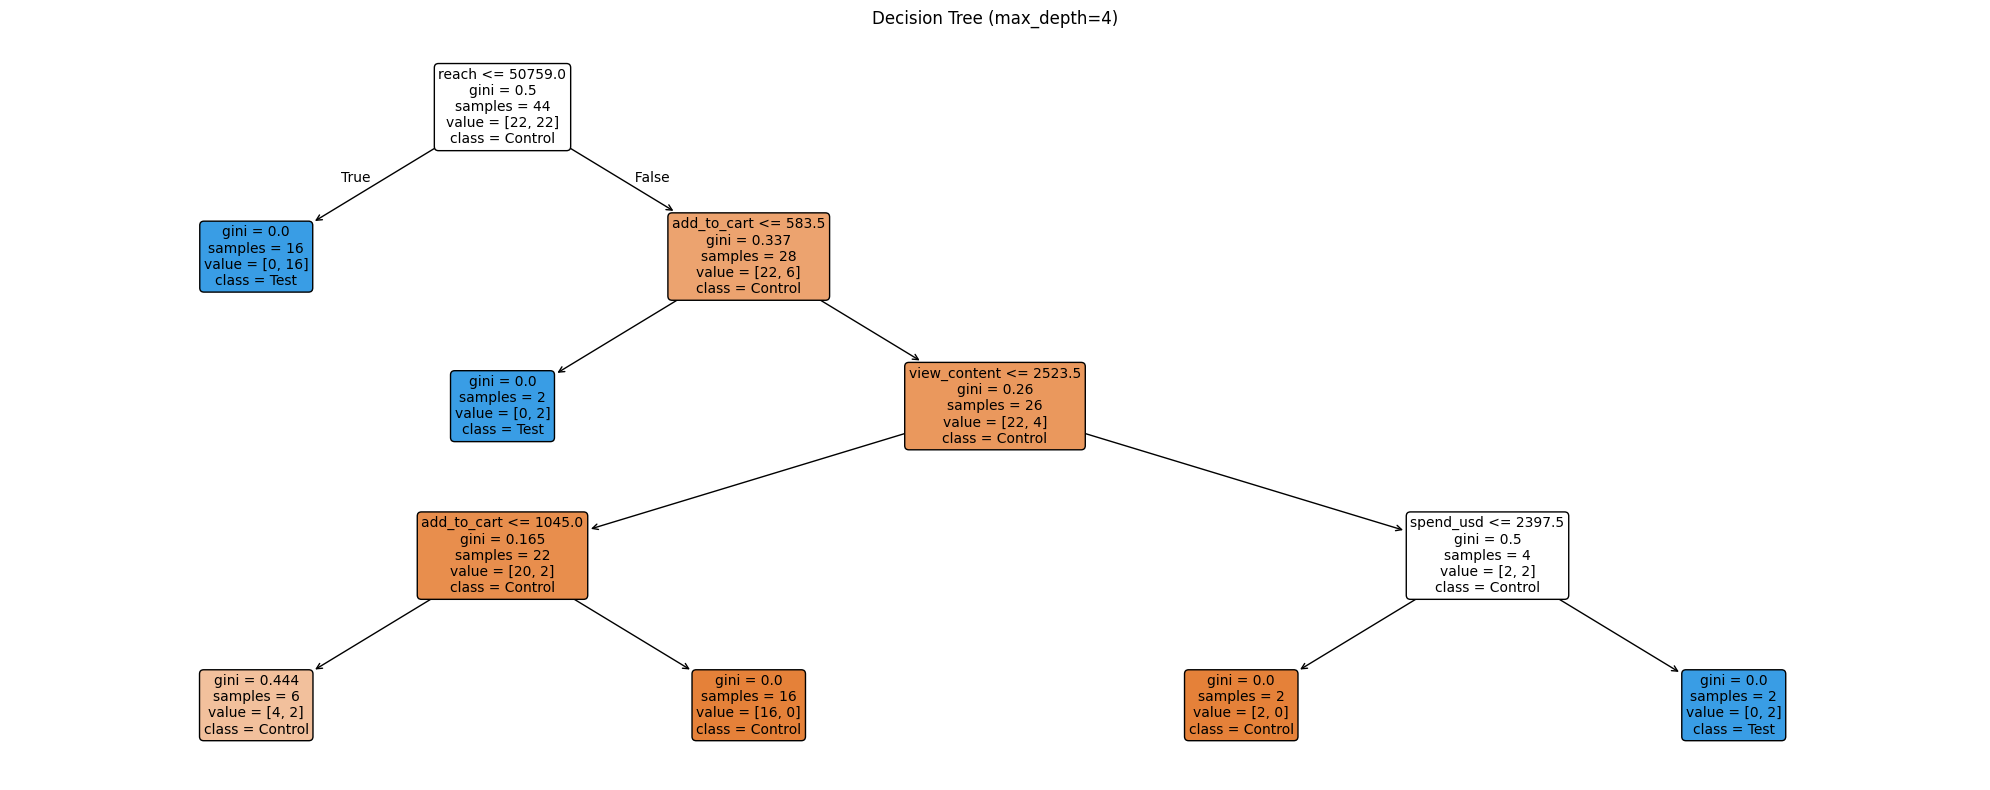

In [7]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=['Control', 'Test'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

## 4. Mô hình Rừng ngẫu nhiên (Random Forest Classifier)

In [8]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print('=== Random Forest ===')
print(f'Accuracy: {acc_rf:.4f}')
print(f'ROC-AUC:  {auc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Control', 'Test']))

=== Random Forest ===
Accuracy: 0.7333
ROC-AUC:  0.7857

              precision    recall  f1-score   support

     Control       0.67      0.86      0.75         7
        Test       0.83      0.62      0.71         8

    accuracy                           0.73        15
   macro avg       0.75      0.74      0.73        15
weighted avg       0.76      0.73      0.73        15



## 5. So sánh đường cong ROC (ROC Curve Comparison)

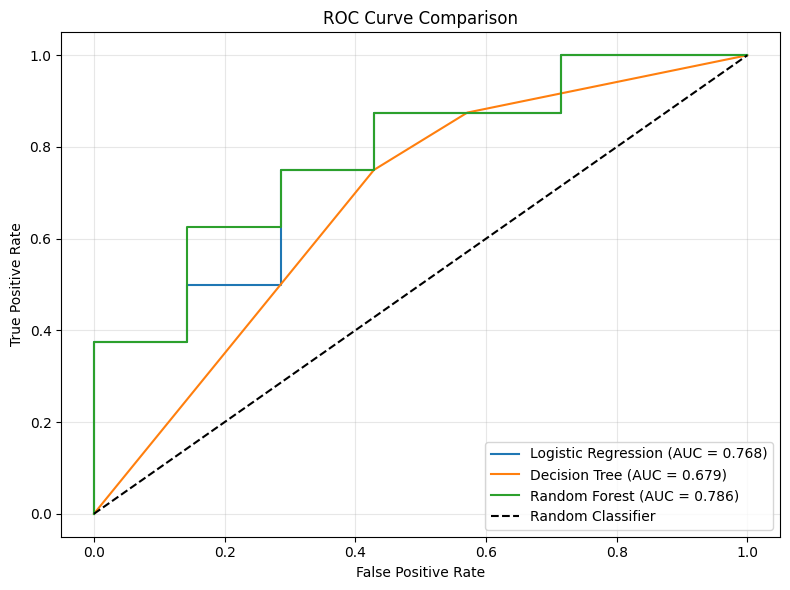

In [9]:
plt.figure(figsize=(8, 6))

models = [
    ('Logistic Regression', y_prob_lr, auc_lr),
    ('Decision Tree', y_prob_dt, auc_dt),
    ('Random Forest', y_prob_rf, auc_rf)
]

for name, probs, auc in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Bảng tổng hợp so sánh các mô hình (Model Comparison Summary)

In [10]:
# Cross-validation scores
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_lr = cross_val_score(LogisticRegression(max_iter=1000), X_train_scaled, y_train, cv=cv, scoring='roc_auc')
cv_dt = cross_val_score(DecisionTreeClassifier(max_depth=4, random_state=42), X_train, y_train, cv=cv, scoring='roc_auc')
cv_rf = cross_val_score(RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42), X_train, y_train, cv=cv, scoring='roc_auc')

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Test Accuracy': [acc_lr, acc_dt, acc_rf],
    'Test AUC': [auc_lr, auc_dt, auc_rf],
    'CV AUC Mean': [cv_lr.mean(), cv_dt.mean(), cv_rf.mean()],
    'CV AUC Std': [cv_lr.std(), cv_dt.std(), cv_rf.std()]
})

comparison = comparison.round(4)
print(comparison.to_string(index=False))

              Model  Test Accuracy  Test AUC  CV AUC Mean  CV AUC Std
Logistic Regression         0.6667    0.7679        0.900      0.1225
      Decision Tree         0.6667    0.6786        0.715      0.1972
      Random Forest         0.7333    0.7857        0.875      0.1285


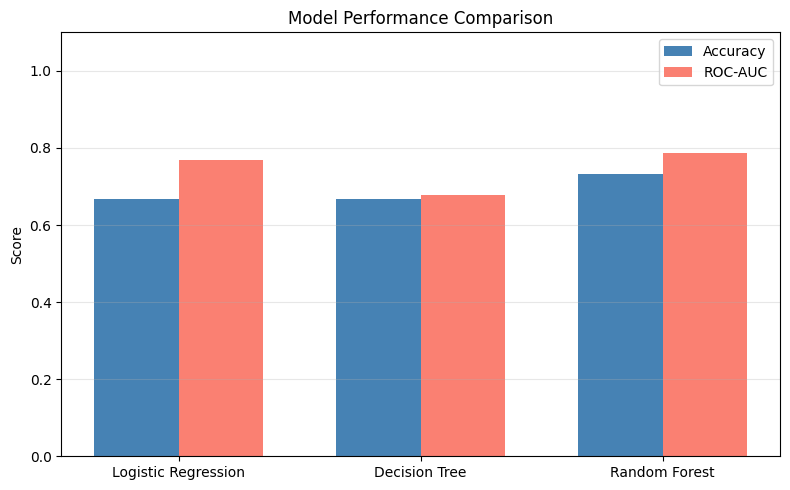

In [11]:
plt.figure(figsize=(8, 5))
x = np.arange(len(comparison))
width = 0.35

plt.bar(x - width/2, comparison['Test Accuracy'], width, label='Accuracy', color='steelblue')
plt.bar(x + width/2, comparison['Test AUC'], width, label='ROC-AUC', color='salmon')

plt.xticks(x, comparison['Model'])
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Độ quan trọng đặc trưng của Rừng ngẫu nhiên (Feature Importance - Random Forest)

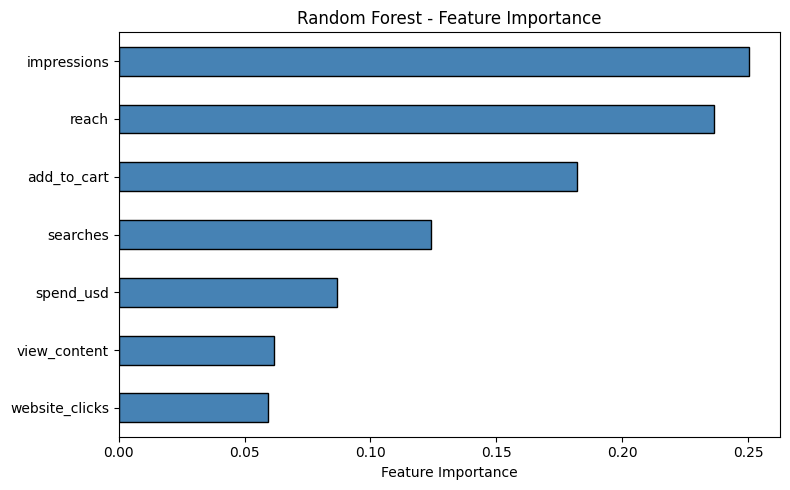

Feature Importances:
impressions       0.2502
reach             0.2366
add_to_cart       0.1819
searches          0.1240
spend_usd         0.0867
view_content      0.0616
website_clicks    0.0591
dtype: float64


In [12]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances_sorted.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Feature Importance')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

print('Feature Importances:')
print(importances.sort_values(ascending=False).round(4))

In [13]:
# Logistic Regression Coefficients
lr_coef = pd.Series(
    np.abs(log_reg.coef_[0]),
    index=feature_cols
).sort_values(ascending=False)

print('Logistic Regression - Absolute Coefficients (after scaling):')
print(lr_coef.round(4))

Logistic Regression - Absolute Coefficients (after scaling):
add_to_cart       1.2382
impressions       0.9727
reach             0.7040
spend_usd         0.6880
searches          0.5371
view_content      0.4529
website_clicks    0.4004
dtype: float64


## INTERPRETATION & BUSINESS INSIGHTS

**1. Ý nghĩa của việc phân loại thành công:**
- Các mô hình phân loại (đặc biệt là Random Forest và Logistic Regression) đạt được hiệu suất phân biệt Control vs Test tốt. Điều này chứng minh rằng **chiến dịch quảng cáo Test và Control tạo ra hai hồ sơ dữ liệu (data profiles) vận hành rất khác nhau**, chứ không chỉ là sự ngẫu nhiên.

**2. Tại sao mô hình phân biệt được? (Giải thích mô hình):**
- Dựa trên **Feature Importance** của Random Forest và hệ số hồi quy của Logistic Regression, các đặc trưng như `reach` và `impressions` đóng vai trò quan trọng nhất trong việc phân biệt hai nhóm.
- Nhóm **Control** đặc trưng bởi lượng hiển thị (`impressions`) và lượt tiếp cận (`reach`) lớn hơn rất nhiều (do cơ chế thầu/phân phối ngân sách tự động hướng đến số đông).
- Nhóm **Test** đặc trưng bởi chi phí trung bình ngày (`spend_usd`) cao hơn nhưng bù lại có tỷ lệ click (`website_clicks`) và tìm kiếm (`searches`) tốt hơn tương ứng với lượng ngân sách bỏ ra.

**3. Kết luận từ góc độ Leakage:**
- Bằng việc loại bỏ `purchase` ra khỏi danh sách đặc trưng đầu vào, ta đảm bảo mô hình phân loại đánh giá khách quan các hành vi trong phễu mà không bị thiên lệch bởi kết quả cuối cùng của A/B test. Điều này giúp khẳng định sự khác biệt giữa hai chiến dịch nằm ở hành vi chuyển đổi phễu chứ không chỉ ở kết quả số lượng đơn hàng.
